In [1]:
from General_Relativity import *

# Friedmann Equations

The goal of this note book is to derive the Friedmann equations from the FLRW metric using the General_Relativity library.
The FLRW metric is given by (see Wikipedia: https://en.wikipedia.org/wiki/Friedmann%E2%80%93Lema%C3%AEtre%E2%80%93Robertson%E2%80%93Walker_metric):
$${\displaystyle {\rm {d}}s^{2}=c^{2}{\rm {d}}t^{2}-a(t)^{2}\left({\frac {{\rm {d}}r^{2}}{1-kr^{2}}}+r^{2}   ({\rm {d}}\theta ^{2}+\sin ^{2}\theta \;{\rm {d}}\phi ^{2})    \right   )}$$

The Friedmann equations are thus : 
$${\displaystyle 3\left({\frac {1}{c^{2}}}{\frac {{\dot {a}}^{2}}{a^{2}}}+{\frac {K}{a^{2}}}\right)={\frac {8\pi G}{c^{2}}}\rho }$$
$${\displaystyle -2{\frac {1}{c^{2}}}{\frac {\ddot {a}}{a}}-{\frac {1}{c^{2}}}{\frac {{\dot {a}}^{2}}{a^{2}}}-{\frac {K}{a^{2}}}={\frac {8\pi G}{c^{4}}}P}$$

With $K = k/a$

### FLRW Metric

In [2]:
FLRW

Matrix([
[c**2,                      0,             0,                       0],
[   0, -a(t)**2/(-k*r**2 + 1),             0,                       0],
[   0,                      0, -r**2*a(t)**2,                       0],
[   0,                      0,             0, -r**2*a(t)**2*sin(θ)**2]])

In [3]:
FLRW.inv()

Matrix([
[c**(-2),                    0,                 0,                           0],
[      0, (k*r**2 - 1)/a(t)**2,                 0,                           0],
[      0,                    0, -1/(r**2*a(t)**2),                           0],
[      0,                    0,                 0, -1/(r**2*a(t)**2*sin(θ)**2)]])

### Christoffel Symbols

In [4]:
Display_Christoffel_Symbols(FLRW)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

...

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### Riemann Tensor

In [11]:
Display_Riemann(FLRW)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

...

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### Ricci Tensor

In [12]:
R_tensor = All_Ricci(FLRW)
Display_Ricci(FLRW)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### Ricci Scalar

In [13]:
R = Ricci_Scalar(FLRW)
Display_Ricci_Scalar(FLRW)

<IPython.core.display.Latex object>

### Perfect fluid Metric

In [14]:
rho, p = smp.symbols('rho p')

In [15]:
T = np.zeros([4,4], dtype='object')
T = Matrix(T)

T[0,0] = rho * c**2
T[1,1] = p * a(t)**2/(1-k*r**2)
T[2,2] = p * a(t)**2 * r**2
T[3,3] = p * a(t)**2 * r**2 * smp.sin(theta)**2

In [16]:
T

⎡ 2                                              ⎤
⎢c ⋅ρ      0           0               0         ⎥
⎢                                                ⎥
⎢          2                                     ⎥
⎢       p⋅a (t)                                  ⎥
⎢ 0    ──────────      0               0         ⎥
⎢           2                                    ⎥
⎢      - k⋅r  + 1                                ⎥
⎢                                                ⎥
⎢                     2  2                       ⎥
⎢ 0        0       p⋅r ⋅a (t)          0         ⎥
⎢                                                ⎥
⎢                                 2  2       2   ⎥
⎣ 0        0           0       p⋅r ⋅a (t)⋅sin (θ)⎦

### Einstein Equation

### $${\displaystyle R_{\mu \nu }\ -\ {\frac {1}{2}}\,g_{\mu \nu }\,R\ +\ \Lambda \ g_{\mu \nu }\ = \frac{8\pi G}{c^4} T_{\mu \nu }}$$

In [17]:
Lambda = smp.symbols('Lambda')
Lambda = 0

In [18]:
A1 = R_tensor[0,0] - 1/2*FLRW[0,0]*R + Lambda*FLRW[0,0]
A1 = simplify(A1.subs([ (smp.diff(a(t),t,2), a_Dot(t)) , (smp.diff(a(t),t), a_dot(t)) ]))

B1 = 8*smp.pi*G/c**4 * T[0,0]
B1 = simplify(B1)

In [19]:
A = R_tensor - 1/2*FLRW*R + Lambda*FLRW
B = 8*smp.pi*G/c**4 * T

# Replace da(t)/dt by a_dot and siplify
A = simplify(A.subs([ (smp.diff(a(t),t,2), a_Dot(t)) , (smp.diff(a(t),t), a_dot(t)) ])) 
B = simplify(B.subs([ (smp.diff(a(t),t,2), a_Dot(t)) , (smp.diff(a(t),t), a_dot(t)) ]))

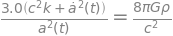

In [20]:
init_printing()

display(Eq(A[0,0], B[0,0]).subs(Lambda, 0))

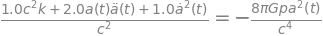

In [21]:
F = k*r**2 - 1 
display(Eq(A[1,1]*F, B[1,1]*F).subs(Lambda, 0))

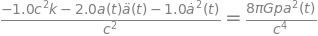

In [22]:
display(Eq(A[2,2]/r**2, B[2,2]/r**2).subs(Lambda, 0))

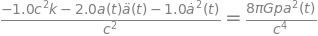

In [23]:
display(Eq(A[3,3] / (r*sin(theta))**2, B[3,3] / (r*sin(theta))**2).subs(Lambda, 0))